# 2D Proof-of-Concept Experiments

Validates the primal-dual OT training algorithm on a small 2D source
(Gaussian) and target (3-component Gaussian mixture) before moving to
image data. Corresponds to Section 5.1 of the thesis.

Reusable code (models, optimizers, training loop, plotting, metrics) lives
in `src/`; this notebook only sets up the experiment-specific data and
hyperparameter sweeps.

In [30]:
import os
import sys

sys.path.insert(0, os.path.abspath('../src'))  # make src/ importable

import torch
import matplotlib.pyplot as plt

from data import sample_gaussian, sample_mog, random_subset
from models import Generator, Critic
from optimizers import (
    SGD_update, adam_update, optimistic_adam_update,
    anchored_adam_update, anchored_optimistic_adam_update,
)
from plotting import plot_source_target
from training import train_2d

LOG_DIR = '../runs/2D/'      # TensorBoard event files
MODEL_DIR = '../models/2D/'  # G.pt / D.pt checkpoints
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

torch.set_num_threads(os.cpu_count())

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


Using device: cpu


## Data

In [31]:
# Sample sizes
n_samples = 100_000    # total source/target points
subset_size = 5_000    # sample size used for plotting
seed = SEED

In [32]:
# Source distribution: a single Gaussian
noise_mu = [-2.0, -2.0]
noise_cov = [[0.3, -0.1],
             [-0.1, 0.3]]

source_points = sample_gaussian(n_samples, noise_mu, noise_cov, seed=seed)


In [33]:
# Target distribution: 3-component Gaussian mixture
target_means = [
    torch.tensor([2.0, 3.0]),    # top right
    torch.tensor([0.0, 0.0]),    # middle
    torch.tensor([-4.0, -1.0]),  # left
]
target_covs = [
    torch.tensor([[0.2, 0.0], [0.0, 0.2]]),
    torch.tensor([[0.2, 0.0], [0.0, 0.2]]),
    torch.tensor([[0.2, 0.0], [0.0, 0.2]]),
]
weights = [0.4, 0.4, 0.2]

target_points = sample_mog(n_samples, target_means, target_covs, weights, seed=seed)

# Cluster centers in the *raw* (uncentered) frame -- used when centered=False.
target_centers_raw = torch.stack(target_means)


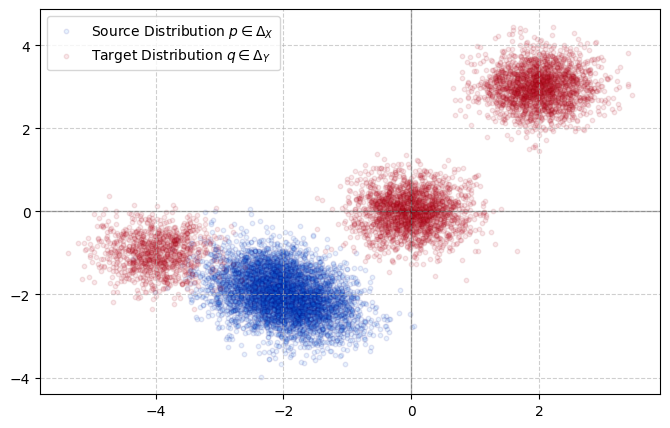

In [34]:
source_for_plotting = random_subset(source_points, subset_size, seed=seed)
target_for_plotting = random_subset(target_points, subset_size, seed=seed)

plot_source_target(source_for_plotting, target_for_plotting,
                    title="Initial State: Source and Target Distributions")

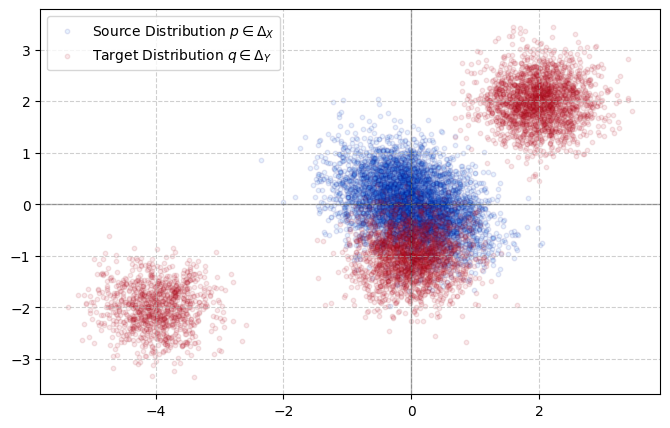

In [35]:
# Mean-centered versions -- used by default in all experiments below.
source_points_centered = source_points - source_points.mean(dim=0, keepdim=True)
target_points_centered = target_points - target_points.mean(dim=0, keepdim=True)

# Cluster centers in the centered coordinate system, used for mode-coverage logging.
target_centers_centered = torch.stack(target_means) - target_points.mean(dim=0, keepdim=True)

source_centered_for_plotting = random_subset(source_points_centered, subset_size, seed=seed)
target_centered_for_plotting = random_subset(target_points_centered, subset_size, seed=seed)

plot_source_target(source_centered_for_plotting, target_centered_for_plotting,
                    title="Initial State (Centered): Source vs. Target Distributions")


## Experiment runner

Thin wrapper around `train()` (in `src/training.py`): builds a fresh
Generator/Critic pair and picks the centered or raw data before dispatching
to the shared training loop.


In [ ]:
def run_experiment(
    name,
    optimizer=SGD_update,
    gamma=1e-4,
    eta=1e-4,
    batch_size=64,
    sigma=0.01,
    num_epochs=200,
    centered=True,
    seed=SEED,
    device=device,
):
    torch.manual_seed(seed)
    G = Generator().to(device)
    D = Critic().to(device)

    if centered:
        src, tgt, centers = source_points_centered, target_points_centered, target_centers_centered
    else:
        src, tgt, centers = source_points, target_points, target_centers_raw

    return train_2d(
        G=G, D=D,
        source_points=src,
        target_points=tgt,
        optimizer_fn=optimizer,
        gamma=gamma, eta=eta, sigma=sigma,
        num_epochs=num_epochs, batch_size=batch_size,
        run_name=name, seed=seed,
        target_centers=centers, device=device,
        log_dir=LOG_DIR, model_dir=MODEL_DIR,
    )


## Experiments

### Experiment 01 -- Learning rate sweep (SGD)

Section 5.1.1 of the thesis.

In [ ]:
for lr in [0.01, 0.001, 0.0001]:
    run_experiment(name=f'E01_lr_{lr}', optimizer=SGD_update, gamma=lr, eta=lr, num_epochs=200)


### Experiment 02 -- Optimizer sweep

Section 5.1.2 of the thesis. All runs use `beta1=0.5`.

In [ ]:
opt_labels = {
    SGD_update: 'SGD',
    adam_update: 'Adam',
    optimistic_adam_update: 'O_Adam',
    anchored_adam_update: 'A_Adam',
    anchored_optimistic_adam_update: 'A_O_Adam',
}
for opt in [anchored_adam_update, anchored_optimistic_adam_update]:
    run_experiment(name=f'E02_beta1_0.5_{opt_labels[opt]}', optimizer=opt)

### Experiment 03 -- Reparametrization noise ($\sigma$) sweep

Section 5.1.3 of the thesis.

In [ ]:
for s in [0, 0.01, 0.1, 1, 2]:
    run_experiment(name=f'E03_Sigma_{s}', sigma=s, optimizer=anchored_optimistic_adam_update)

### Experiment 04 -- Batch-size sweep (matched updates)

Section 5.1.4 of the thesis. `num_epochs` is adjusted per batch size so the
total number of gradient updates stays roughly constant (~312k) -- this
isolates the effect of batch noise from the effect of training duration.


In [ ]:
target_updates = 312_000
for batch in [32, 64, 128]:
    epochs = max(1, target_updates // (n_samples // batch))
    run_experiment(name=f'E04_Batch Size_{batch}', batch_size=batch, optimizer=anchored_optimistic_adam_update)